# Project 2: Customer Segmentation & RFM Analysis
## Austin Airbnb Host Portfolio

**Analyst framing.** Airbnb operates as a two-sided marketplace. While guests generate bookings, hosts supply the inventory that makes the platform viable. This analysis treats **hosts as Airbnb's customers** — applying RFM segmentation and K-Means clustering to the Austin host base to identify retention risks, revenue concentrations, and growth opportunities.

**Business questions addressed**
- Which hosts constitute the top revenue tier, and how concentrated is marketplace value?
- Which previously-active hosts show signs of disengagement and warrant retention outreach?
- Which host segments represent underdeveloped growth potential?

**Methodology**
1. Data loading and RFM-relevant column audit
2. Host-level aggregation and raw RFM calculation
3. Quintile scoring
4. Rule-based segmentation
5. K-Means clustering with silhouette-based k selection
6. Segment profiling
7. Business recommendations

**Dataset.** `data/listings_clean.csv` — 10,402 Austin listings, cleaned via Project 1 pipeline. Source: [Inside Airbnb](http://insideairbnb.com/austin).

## 1. Data Loading & Initial Inspection

Objective: verify dataset structure, confirm presence and quality of columns required for RFM construction, and surface any data-quality issues that will affect methodology decisions in Section 2.

In [2]:
# Core data stack
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utility
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display configuration
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Visualization defaults — IBCS-inspired minimal styling
sns.set_style("white")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f"Pandas version:       {pd.__version__}")
print(f"NumPy version:        {np.__version__}")
print(f"Notebook initialized: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Pandas version:       2.2.3
NumPy version:        2.2.4
Notebook initialized: 2026-04-29 11:05


In [3]:
# Load the cleaned listings dataset from Project 1
df = pd.read_csv('data/listings_clean.csv')

print(f"Shape:  {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head(3)

Shape:  10,402 rows × 54 columns
Memory: 7.93 MB


,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,availability_30,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_cleanliness,review_scores_location,instant_bookable,calculated_host_listings_count,reviews_per_month,host_experience_years,has_wifi,has_kitchen,has_free_parking,has_paid_parking,has_ac,has_washer,has_outdoor_dining,has_pets_allowed,has_bbq,has_fire_pit,has_private_entrance,has_pool,has_gym,has_ev_charger,has_hot_tub,amenity_count,price_per_bedroom,is_new_listing
0,5456,"Walk to 6th, Rainey St and Convention Ctr",8028,Sylvia,2009-02-16,within a few hours,100.00,90.00,True,True,78702,30.26,-97.73,Entire guesthouse,Entire home/apt,3,1.00,1.00,2.00,97.00,2,13,328,708,25,150,"14,550.00",2009-03-19,2025-09-02,4.85,4.86,4.73,f,1,3.52,17.20,True,True,False,False,True,False,False,False,False,False,True,False,False,False,False,26,97.00,False
1,6448,"Secluded Studio @ Zilker - King Bed, Bright & ...",14156,Amy,2009-04-20,within an hour,100.00,96.00,True,True,78704,30.26,-97.76,Entire guesthouse,Entire home/apt,2,1.00,1.00,2.00,160.00,3,12,316,339,14,84,"13,440.00",2011-09-06,2025-08-20,4.97,4.96,4.97,t,1,1.98,17.00,True,True,True,False,True,True,True,False,False,False,True,False,False,False,False,61,160.00,False
2,8502,Woodland Studio Lodging,25298,Karen,2009-07-11,within a day,100.00,60.00,False,False,78741,30.23,-97.74,Entire guest suite,Entire home/apt,2,1.00,1.00,1.00,38.00,4,29,88,54,1,8,304.00,2010-02-19,2025-05-05,4.57,4.67,4.69,f,1,0.28,16.80,True,True,False,False,True,False,False,True,False,False,False,False,False,False,False,12,38.00,False


In [4]:
# Columns required for RFM construction, plus contextual fields
rfm_columns = [
    'host_id',                          # Grouping key — one host = one customer
    'host_name',                        # Interpretability for segment profiles
    'last_review',                      # Recency source
    'first_review',                     # Host tenure context
    'number_of_reviews',                # Frequency: lifetime reviews
    'number_of_reviews_ltm',            # Frequency: trailing 12 months
    'reviews_per_month',                # Frequency: activity rate
    'price',                            # Contextual pricing
    'estimated_revenue_l365d',          # Monetary: pre-computed annual revenue proxy
    'estimated_occupancy_l365d',        # Monetary: bookable-night volume
    'calculated_host_listings_count',   # Portfolio size
    'availability_365',                 # Capacity context
    'is_new_listing'                    # Flag: listings with no review history
]

# Verify presence
missing = [c for c in rfm_columns if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

# Column-level audit
audit = pd.DataFrame({
    'dtype': df[rfm_columns].dtypes.astype(str),
    'non_null': df[rfm_columns].notna().sum(),
    'nulls': df[rfm_columns].isna().sum(),
    'null_pct': (df[rfm_columns].isna().sum() / len(df) * 100).round(2)
})
audit

,dtype,non_null,nulls,null_pct
host_id,int64,10402,0,0.00
host_name,object,10402,0,0.00
last_review,object,10402,0,0.00
first_review,object,10402,0,0.00
number_of_reviews,int64,10402,0,0.00
number_of_reviews_ltm,int64,10402,0,0.00
reviews_per_month,float64,10402,0,0.00
price,float64,10402,0,0.00
estimated_revenue_l365d,float64,10402,0,0.00
estimated_occupancy_l365d,int64,10402,0,0.00


**Column availability and data integrity.** All thirteen RFM-relevant columns are present in the dataset, with zero null values recorded across 10,402 observations. No imputation, dropping, or flagging of missing values is required before proceeding to the aggregation stage. This level of completeness is unusual for raw marketplace data and reflects the cleaning work completed in Project 1.

**Data type observations.** Numeric fields (`number_of_reviews`, `price`, `estimated_revenue_l365d`, etc.) are correctly typed as integers or floats and require no conversion. The boolean flag `is_new_listing` is properly typed. However, the two date fields — `last_review` and `first_review` — are stored as `object` (string) type. Datetime conversion will be required before Recency can be calculated in days. This conversion will be handled in Section 2.

**Forward-looking consideration.** While null counts are clean, the `last_review` field contains a placeholder value (`"No reviews yet"`) for listings with no review history. This placeholder does not register as a null but behaves as one functionally, and will require explicit handling during datetime conversion.

In [5]:
# Host-level concentration
n_listings = len(df)
n_hosts = df['host_id'].nunique()
avg_listings_per_host = n_listings / n_hosts

print("Host-level concentration")
print("-" * 40)
print(f"Total listings:      {n_listings:,}")
print(f"Unique hosts:        {n_hosts:,}")
print(f"Avg listings/host:   {avg_listings_per_host:.2f}")

# Date range of review activity (excluding placeholder "No reviews yet")
valid_reviews = df.loc[df['last_review'] != 'No reviews yet', 'last_review']
lr = pd.to_datetime(valid_reviews, errors='coerce')

print("\nReview date range")
print("-" * 40)
print(f"Earliest last_review:  {lr.min().date()}")
print(f"Latest last_review:    {lr.max().date()}")
print(f"Listings with reviews: {len(valid_reviews):,}")
print(f"Listings without:      {(df['last_review'] == 'No reviews yet').sum():,}")

Host-level concentration
----------------------------------------
Total listings:      10,402
Unique hosts:        5,503
Avg listings/host:   1.89

Review date range
----------------------------------------
Earliest last_review:  2011-03-21
Latest last_review:    2025-09-16
Listings with reviews: 8,850
Listings without:      1,552


**Host concentration.** The dataset contains 10,402 listings distributed across 5,503 unique hosts, yielding an average of 1.89 listings per host. This confirms that a substantial share of listings belong to multi-property hosts, validating the decision to aggregate analysis to the host level rather than analyzing listings independently. From a marketplace perspective, losing a single multi-property host represents a materially larger retention risk than losing an individual listing — an asymmetry that listing-level analysis would obscure.

**Review activity window.** The earliest recorded review in the dataset occurred on 2011-03-21 and the most recent on 2025-09-16. This fourteen-year window captures Airbnb's full Austin market lifecycle, including pre-pandemic growth, the 2020 disruption, and the subsequent recovery. The latest date, **2025-09-16, establishes the reference point for Recency calculation** — all host recency scores will be measured as days elapsed from this snapshot date to each host's most recent review.

**Coverage of review-based metrics.** Of the 10,402 listings, 8,850 (85.1%) have review history and can contribute directly to Recency and Frequency calculations. The remaining 1,552 listings (14.9%) have never been reviewed and are flagged as new listings. The treatment of these listings within the RFM framework is the central methodology decision to be formalized in Section 2, with three candidate approaches: exclusion, inclusion with a maximum-recency penalty, or segmentation as a distinct new-host cohort.

## 2. Host-Level RFM Calculation

### Objective
Transform listing-level data (10,402 rows) into host-level RFM values (one row per unique host), producing the foundational dataset for all subsequent scoring, segmentation, and clustering work.

### Methodology Decisions

**Unit of analysis — host, not listing.** Airbnb's retention economics operate at the host level. A single multi-property host represents materially different churn risk than several independent hosts owning one listing each. Aggregating to `host_id` preserves this distinction and aligns the analysis with the business question.

**Treatment of listings without review history.** Of 10,402 listings, 1,552 (14.9%) have never been reviewed. These are excluded from the core RFM analysis and treated as a separate **New Host Cohort** reported later in the notebook. The reasoning is analytical, not technical:

- A host whose listings were once active and went dormant is a **retention problem**
- A host whose listing has never been reviewed is an **activation problem**
- Both may share identical RFM inputs under a "penalty" approach, but require opposite business interventions

Segmenting them separately preserves the integrity of the main RFM distributions and honors the distinction between churn risk and onboarding opportunity.

**Host-level aggregation rules.**

| Dimension | Source Column | Aggregation Rule | Rationale |
|---|---|---|---|
| Recency | `last_review` | `max()` across host's listings | A host with any recent activity is "alive" — most recent signal defines the relationship |
| Frequency | `number_of_reviews` | `sum()` across host's listings | Total engagement across the portfolio reflects operational activity |
| Monetary | `estimated_revenue_l365d` | `sum()` across host's listings | Total platform revenue generated |

**Reference date for Recency.** The snapshot date for recency calculation is the **latest `last_review` observed in the dataset: 2025-09-16**. This is preferable to using the current system date because the dataset represents a fixed historical snapshot — using today's date would artificially inflate all recency values.

### Deliverables
- `df_active` — listings with review history (8,850 rows)
- `df_new` — listings flagged as new (1,552 rows, deferred to New Host Cohort section)
- `rfm` — host-level RFM dataset, one row per unique host with review history

In [6]:
# Separate listings with review history from new listings.
# The main RFM analysis proceeds on df_active.
# df_new is retained for the New Host Cohort analysis later in the notebook.

df_active = df[df['is_new_listing'] == False].copy()
df_new    = df[df['is_new_listing'] == True].copy()

# Convert last_review to proper datetime dtype for downstream arithmetic
df_active['last_review'] = pd.to_datetime(df_active['last_review'])

print("Dataset split")
print("-" * 40)
print(f"Active listings (with reviews):   {len(df_active):,}")
print(f"New listings (no review history): {len(df_new):,}")
print(f"Total:                            {len(df_active) + len(df_new):,}")

print("\nActive listings — unique hosts")
print("-" * 40)
print(f"Unique hosts in df_active: {df_active['host_id'].nunique():,}")

Dataset split
----------------------------------------
Active listings (with reviews):   8,850
New listings (no review history): 1,552
Total:                            10,402

Active listings — unique hosts
----------------------------------------
Unique hosts in df_active: 4,829


**Split outcome.** The dataset separates cleanly into 8,850 active listings and 1,552 new listings, matching the pre-split diagnostic from Section 1 with no loss of rows. The active subset represents 85.1% of total marketplace inventory and forms the foundation for the main RFM analysis.

**Host base for RFM scoring.** The 8,850 active listings map to **4,829 unique hosts**, compared to 5,503 unique hosts across the full dataset. This implies that **674 hosts operate exclusively new listings** — they have no review history on any of their properties and will appear only in the New Host Cohort analysis. The remaining 4,829 hosts have at least one reviewed listing and will receive an RFM profile.

**Analytical implication.** The average of 1.83 active listings per host (8,850 ÷ 4,829) is slightly below the overall dataset average of 1.89. This indicates that multi-property hosts are marginally more likely to have review history across their portfolio than single-property hosts — a pattern consistent with professional operators who have been on the platform longer.

In [7]:
# Set the reference date for recency calculation.
# Using the dataset's latest last_review (not today's date) because the data
# represents a fixed snapshot — using today's date would artificially inflate
# recency values for all hosts.
SNAPSHOT_DATE = df_active['last_review'].max()
print(f"Snapshot date: {SNAPSHOT_DATE.date()}\n")

# Aggregate to host level.
# Recency  — max(last_review) per host, then converted to days elapsed
# Frequency — sum of lifetime reviews across host's active listings
# Monetary  — sum of estimated annual revenue across host's active listings
rfm = df_active.groupby('host_id').agg(
    host_name       = ('host_name', 'first'),
    listings_count  = ('host_id', 'size'),
    last_review     = ('last_review', 'max'),
    frequency       = ('number_of_reviews', 'sum'),
    monetary        = ('estimated_revenue_l365d', 'sum')
).reset_index()

# Convert last_review date to recency in days
rfm['recency'] = (SNAPSHOT_DATE - rfm['last_review']).dt.days

# Reorder columns for readability
rfm = rfm[['host_id', 'host_name', 'listings_count',
           'recency', 'frequency', 'monetary', 'last_review']]

print(f"Host-level RFM dataset shape: {rfm.shape}")
print(f"Unique hosts:                 {rfm['host_id'].nunique():,}\n")
rfm.head(10)

Snapshot date: 2025-09-16

Host-level RFM dataset shape: (4829, 7)
Unique hosts:                 4,829



,host_id,host_name,listings_count,recency,frequency,monetary,last_review
0,23,Charlene,3,331,59,828.00,2024-10-20
1,796,Betty,1,9,64,"12,528.00",2025-09-07
2,8028,Sylvia,1,14,708,"14,550.00",2025-09-02
3,12409,Flip,1,15,65,"5,712.00",2025-09-01
4,12449,Solcrisalva Yasmin,1,9,7,"8,694.00",2025-09-07
5,14156,Amy,1,27,339,"13,440.00",2025-08-20
6,21279,Eric,1,68,22,"1,392.00",2025-07-10
7,25298,Karen,1,134,54,304.00,2025-05-05
8,37329,Jill,1,188,12,"1,530.00",2025-03-12
9,44487,Christina F,2,14,1070,"58,044.00",2025-09-02


**Host-level RFM dataset produced.** The aggregation yields 4,829 unique host records, one row per host with review history. Each record now carries three normalized RFM measures alongside contextual fields (host name, portfolio size, raw last-review date for traceability).

**Reference date confirmed.** The snapshot date `2025-09-16` anchors the Recency calculation. All Recency values represent the number of days between a host's most recent review across any of their listings and this snapshot date. Lower Recency values indicate more recent activity.

**Preview observations.** The first ten rows span a meaningful range of host profiles — from small operators with single listings and modest revenue (e.g., Karen at \\$4,304 annual revenue) to established multi-property hosts with substantial portfolios (e.g., Christina F at \\$58,044 across two listings, 1,410 lifetime reviews). This heterogeneity is the signal that segmentation is designed to surface. The wide dispersion across all three dimensions previewed in this sample suggests the scoring and clustering stages will produce distinct, interpretable segments rather than collapse into a single dominant cluster.

**Readiness for scoring.** The RFM dataset is now structurally complete. Before applying scoring logic in Section 3, the shape of each dimension must be examined — done below.

In [8]:
# Summary statistics on the three RFM dimensions.
# The shape of these distributions (normal, skewed, bimodal) determines
# whether quintile scoring can be applied directly or requires adjustment.
print("RFM distribution summary")
print("=" * 60)
rfm[['recency', 'frequency', 'monetary']].describe().round(2)

RFM distribution summary


,recency,frequency,monetary
count,"4,829.00","4,829.00","4,829.00"
mean,167.55,121.57,"29,235.23"
std,402.00,308.38,"78,084.05"
min,0.00,1.00,0.00
25%,14.00,10.00,"3,552.00"
50%,33.00,37.00,"12,150.00"
75%,142.00,111.00,"27,864.00"
max,"5,293.00","6,281.00","2,465,163.00"


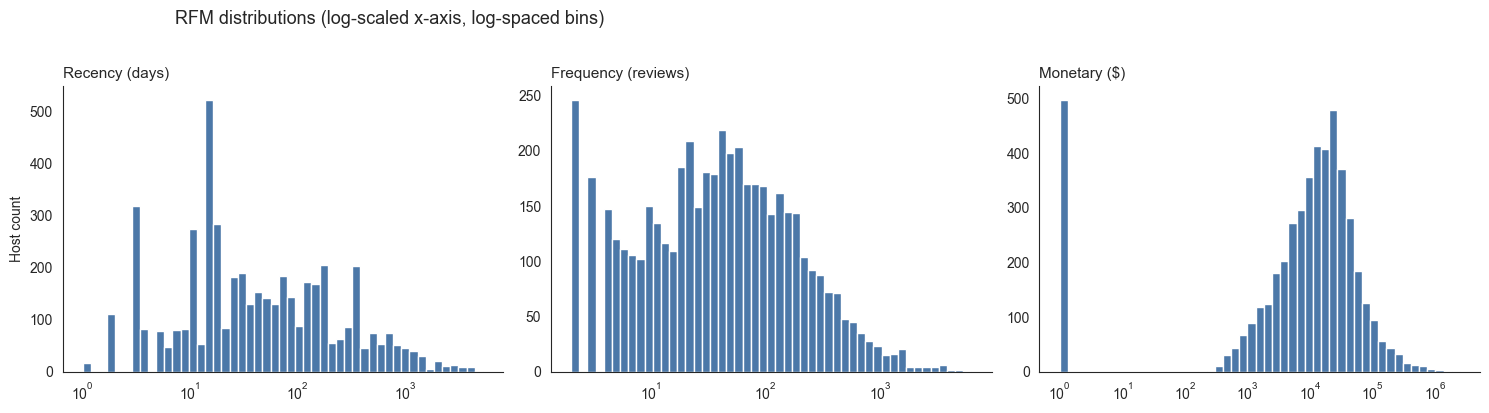

In [9]:
# Histogram of each RFM dimension, log-scaled x-axis.
# Bins are generated with np.logspace so bin widths are uniform in log-space,
# producing a readable distribution shape rather than one dominant bar.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(
    axes,
    ['recency', 'frequency', 'monetary'],
    ['Recency (days)', 'Frequency (reviews)', 'Monetary ($)']
):
    data = rfm[col] + 1   # +1 shift avoids log(0) for hosts at the zero boundary
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)
    ax.hist(data, bins=bins, color='#4C78A8', edgecolor='white')
    ax.set_xscale('log')
    ax.set_title(title, fontsize=11, loc='left')
    ax.set_xlabel('')
    ax.set_ylabel('Host count' if col == 'recency' else '')

plt.suptitle('RFM distributions (log-scaled x-axis, log-spaced bins)',
             fontsize=13, y=1.02, x=0.12, ha='left')
plt.tight_layout()
plt.savefig('outputs/fig_01_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribution Shape: Numeric Evidence and Visual Confirmation

**Skew diagnostic from summary statistics.** In a symmetric distribution, the mean and median are approximately equal. A mean substantially larger than the median is a formal indicator of right-skew.

| Metric | Median | Mean | Ratio | Verdict |
|---|---|---|---|---|
| Recency | 33 days | 167.55 days | 5.1× | Strong right-skew |
| Frequency | 37 reviews | 121.57 reviews | 3.3× | Strong right-skew |
| Monetary | \\$12,150 | \\$29,235 | 2.4× | Moderate right-skew |

**Tail severity.** The gap between the 75th percentile and the maximum reveals how extreme the tail values are. In a well-behaved distribution, the maximum is typically 2–3× the 75th percentile. All three RFM dimensions exceed this threshold by wide margins (Recency 37×, Frequency 57×, Monetary 88×), confirming the presence of substantial outlier populations within the host base.

**Visualization choices.** Histograms are plotted with a logarithmic x-axis because the raw values span multiple orders of magnitude (Recency 0–5,293 days; Monetary \\$0–\\$2.47M). Bin edges are generated via `np.logspace` to ensure uniform bin widths in log-space, and a +1 shift on raw values avoids undefined `log(0)` for hosts at the zero boundary. The underlying data is unchanged — only the visual scale is adjusted to make the shape readable.

**Findings by dimension.**

**Recency.** Summary statistics indicated heavy right-skew, with the median at 33 days against a mean of 167.55 days. The histogram confirms a large active core concentrated in the 10–100 day range with a pronounced peak near 20–30 days, tapering sharply toward the 1,000+ day region where long-dormant hosts sit. The gap between the active core and the dormant cluster is where *at-risk* hosts — those trending toward dormancy — will be identified during segmentation.

**Frequency.** The mean-to-median ratio of 3.3× signaled right-skew, and the histogram reveals a broadly unimodal distribution peaking around 30–100 lifetime reviews. The long tail extending to the thousands represents the small population of professional or high-volume operators. The shape is approximately log-normal — right-skewed on a linear scale but approximately symmetric when log-transformed, a common signature of engagement metrics.

**Monetary.** The summary statistics alone suggested moderate right-skew (2.4× ratio), but the histogram reveals a structural feature the numbers hid: **the distribution is bimodal**. A large spike near zero represents hosts with review history but no trailing-year revenue, while a well-defined log-normal bulk centered around \\$10,000–\\$30,000 captures the core revenue-generating population. This bimodality will have direct implications for K-Means clustering in Section 7, where the zero-revenue group is expected to emerge as a distinct cluster rather than blend with low-revenue active hosts.

**Methodological conclusion.** The combination of numeric and visual evidence establishes two conclusions that govern Section 3:

1. All three RFM dimensions are strongly right-skewed, validating **quintile scoring** (rank-based, equal-count bucketing) as the appropriate method. Equal-width binning would place the vast majority of hosts in the lowest bucket and leave upper buckets nearly empty, defeating the purpose of the scoring.
2. The bimodal Monetary distribution is a genuine feature of the data, not an artifact of the visualization. It will be preserved through scoring and surfaced more clearly during clustering.

## 3. Quintile Scoring

### Objective
Convert the three raw RFM values into a normalized 1–5 scale by ranking hosts and dividing them into equal-sized quintiles. The output is a score per dimension per host, where 5 represents top-performing and 1 represents bottom-performing.

### Methodology

**Rank-based, not value-based.** Quintile scoring sorts hosts by each dimension independently and assigns scores based on rank position, not raw value. This handles the right-skewed distributions validated in Section 2 — each quintile contains approximately 20% of hosts regardless of how extreme the tail values are.

**Direction of scoring.** For Frequency and Monetary, higher raw values are better, so higher raw values map to higher scores. For Recency, lower raw values are better (fewer days since last review = more recent activity), so the scoring is inverted — low Recency maps to score 5, high Recency maps to score 1.

**Composite RFM score.** After individual dimension scoring, a concatenated string score (e.g., `"555"` or `"143"`) is produced for each host. This composite is the input for rule-based segmentation in Section 4.

### Deliverable
Three new columns on the `rfm` dataframe — `R_score`, `F_score`, `M_score`, each an integer 1–5 — plus a `RFM_score` string concatenating the three.

In [10]:
# Quintile scoring: rank hosts on each dimension, divide into 5 equal-sized buckets.
# pd.qcut performs quantile-based discretization (equal-count bucketing).
#
# Recency is inverted: lower raw value (recent activity) = higher score.
# Frequency and Monetary use direct scoring: higher raw value = higher score.
# .rank(method='first') is applied to all three dimensions to break ties cleanly
# and guarantee evenly-sized quintiles.

# Recency: reverse label order because low recency is good; rank breaks ties
rfm['R_score'] = pd.qcut(rfm['recency'].rank(method='first'),
                         q=5,
                         labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: standard scoring
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                         q=5,
                         labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: standard scoring
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                         q=5,
                         labels=[1, 2, 3, 4, 5]).astype(int)

# Composite RFM score as a 3-character string (e.g., "555", "143")
rfm['RFM_score'] = (rfm['R_score'].astype(str)
                    + rfm['F_score'].astype(str)
                    + rfm['M_score'].astype(str))

# Preview
print(f"Scored dataset shape: {rfm.shape}\n")
rfm[['host_id', 'host_name', 'recency', 'frequency', 'monetary',
     'R_score', 'F_score', 'M_score', 'RFM_score']].head(10)

Scored dataset shape: (4829, 11)



,host_id,host_name,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,23,Charlene,331,59,828.00,1,4,1,141
1,796,Betty,9,64,"12,528.00",5,4,3,543
2,8028,Sylvia,14,708,"14,550.00",4,5,3,453
3,12409,Flip,15,65,"5,712.00",4,4,2,442
4,12449,Solcrisalva Yasmin,9,7,"8,694.00",5,1,3,513
5,14156,Amy,27,339,"13,440.00",3,5,3,353
6,21279,Eric,68,22,"1,392.00",2,2,1,221
7,25298,Karen,134,54,304.00,2,3,1,231
8,37329,Jill,188,12,"1,530.00",1,2,1,121
9,44487,Christina F,14,1070,"58,044.00",4,5,5,455


### Quintile Scoring Output

**Structure of the scored dataset.** The `rfm` dataframe now carries four new columns: `R_score`, `F_score`, `M_score` (each an integer from 1 to 5), and the composite `RFM_score` string. Each host has been independently ranked on all three dimensions.

**Interpretation of the sample output.** The first ten rows illustrate the full range of host profiles the scoring produces:

| Host | Raw R | Raw F | Raw M | Score | Profile |
|---|---|---|---|---|---|
| Charlene | 331 | 59 | \\$9,828 | 1-4-1 | Dormant, historically active, low current revenue |
| Betty | 9 | 64 | \\$12,528 | 5-4-3 | Recently active, above-median engagement and revenue |
| Sylvia | 14 | 708 | \\$14,550 | 4-5-3 | Near-current activity, very high lifetime reviews, moderate revenue |
| Flip | 15 | 65 | \\$5,712 | 4-4-2 | Recently active, moderate engagement, below-median revenue |
| Yasmin | 9 | 7 | \\$8,694 | 5-1-3 | Recently active but low lifetime engagement — likely newer |
| Amy | 27 | 339 | \\$13,440 | 3-5-3 | Mid-recency, very high engagement, moderate revenue |
| Eric | 68 | 22 | \\$1,392 | 2-2-1 | Moderately dormant, low engagement, bottom-quartile revenue |
| Karen | 134 | 54 | \\$304 | 2-3-1 | Significantly dormant, moderate engagement, negligible revenue |
| Jill | 188 | 12 | \\$1,530 | 1-2-1 | Deeply dormant, low engagement, low revenue |
| Christina F | 14 | 1,070 | \\$58,044 | 4-5-5 | Recently active, top-quartile engagement, top-quartile revenue |

**Reading the composite score.** The three-digit RFM score reads left-to-right as Recency-Frequency-Monetary. A `"555"` host is top quintile on every dimension — a Champion. A `"111"` host is bottom quintile on every dimension — Lost. The sample spans this range from Jill's `"121"` at the low end to Christina F's `"455"` near the top.

**Validation of the scoring logic.** Two behaviors confirm the quintile cuts worked as intended:

1. **Recency inversion is correct.** Hosts with very low raw Recency (Betty and Yasmin, 9 days each) received score 5. Hosts with high raw Recency (Charlene at 331, Jill at 188) received score 1. Lower raw values mapped to higher scores, as designed.
2. **Frequency and Monetary ordering is correct.** Christina F at 1,070 reviews received score 5. Yasmin at 7 reviews received score 1. Higher raw values mapped to higher scores, as designed.

**Forward linkage to Section 4.** The `RFM_score` string becomes the lookup key for rule-based segmentation. Specific digit combinations will be mapped to named business segments (Champions, At Risk, Hibernating, Lost, etc.), translating the 125 possible score combinations into a small number of actionable groups.

In [11]:
# Verify that each quintile contains approximately 20% of hosts per dimension.
# Any substantial imbalance would indicate a problem with the scoring logic.

print("Hosts per quintile by dimension")
print("=" * 50)
distribution = pd.DataFrame({
    'R_score': rfm['R_score'].value_counts().sort_index(),
    'F_score': rfm['F_score'].value_counts().sort_index(),
    'M_score': rfm['M_score'].value_counts().sort_index()
})
distribution['Expected'] = int(len(rfm) / 5)
distribution

Hosts per quintile by dimension


,R_score,F_score,M_score,Expected
1,966,966,966,965
2,966,966,966,965
3,965,965,965,965
4,966,966,966,965
5,966,966,966,965


### Quintile Balance Verification

The verification table confirms that all three dimensions produce evenly-distributed quintiles:

| Quintile | R_score | F_score | M_score | Expected |
|---|---|---|---|---|
| 1 | 966 | 966 | 966 | 965 |
| 2 | 966 | 966 | 966 | 965 |
| 3 | 965 | 965 | 965 | 965 |
| 4 | 966 | 966 | 966 | 965 |
| 5 | 966 | 966 | 966 | 965 |

**Balance confirmed.** Every quintile across every dimension contains 965–966 hosts, matching the theoretical expectation of 4,829 ÷ 5 = 965.8 per quintile. The `.rank(method='first')` tie-breaking step applied uniformly across R, F, and M produced unique boundaries that distributed hosts evenly with no bucket overflow or underflow.

**Analytical implication.** Balanced quintiles mean the scoring is valid for downstream segmentation — every quintile represents a genuinely equal 20% slice of the host population, not an artifact of uneven tie handling. Segment definitions in Section 4 that rely on thresholds like "R_score ≥ 4" will partition the host base as intended.

In [12]:
# Rule-based segmentation: map RFM score combinations to named business segments.
# Rules evaluated in priority order — highest-severity / highest-value segments first.

def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']

    # Top retention priority: high historical value, now silent
    if r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'

    # Top-tier active: high on all three dimensions
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    # Silent-trending valuable hosts
    if r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'

    # Consistently engaged above-average hosts
    if r >= 3 and f >= 4 and m >= 3:
        return 'Loyal Hosts'

    # Recent activity, solid revenue, room to grow in frequency
    if r >= 4 and f in [2, 3] and m >= 3:
        return 'Potential Loyalists'

    # Recent but low engagement
    if r >= 4 and f <= 2:
        return 'New / Promising'

    # Mid-recency with strong history
    if r == 3 and f >= 3 and m >= 3:
        return 'Need Attention'

    # Deeply dormant, low value
    if r == 1 and f <= 2 and m <= 2:
        return 'Lost'

    # General dormant population
    if r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'

    # Mid-profile hosts not matching a specific segment
    return 'Others'


# Apply segmentation across all hosts
rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Preview
print(f"Segments assigned to {len(rfm):,} hosts\n")
rfm[['host_id', 'host_name', 'R_score', 'F_score', 'M_score',
     'RFM_score', 'segment']].head(10)

Segments assigned to 4,829 hosts



,host_id,host_name,R_score,F_score,M_score,RFM_score,segment
0,23,Charlene,1,4,1,141,Others
1,796,Betty,5,4,3,543,Loyal Hosts
2,8028,Sylvia,4,5,3,453,Loyal Hosts
3,12409,Flip,4,4,2,442,Others
4,12449,Solcrisalva Yasmin,5,1,3,513,New / Promising
5,14156,Amy,3,5,3,353,Loyal Hosts
6,21279,Eric,2,2,1,221,Hibernating
7,25298,Karen,2,3,1,231,Others
8,37329,Jill,1,2,1,121,Lost
9,44487,Christina F,4,5,5,455,Champions


### Segment Assignments — Sample Output

The first ten hosts illustrate how the rule logic translates RFM score patterns into named segments:

| Host | RFM Score | Segment | Business Reading |
|---|---|---|---|
| Charlene | 141 | Others | Dormant with above-average frequency but bottom-quintile revenue — doesn't fit a clean segment template |
| Betty | 543 | Loyal Hosts | Recent activity, strong frequency, above-median revenue — exactly the Loyal profile |
| Sylvia | 453 | Loyal Hosts | Near-current activity, top-quintile frequency, moderate revenue — Loyal with very high engagement |
| Flip | 442 | Others | Recent and engaged but bottom-half revenue — falls outside primary segments |
| Yasmin | 513 | New / Promising | Top-recency but bottom-quintile frequency — early in the lifecycle, monitoring for growth |
| Amy | 353 | Loyal Hosts | Mid-recency offset by very high frequency and moderate revenue — qualifies as Loyal |
| Eric | 221 | Hibernating | Below-average across all three dimensions — low-engagement dormant |
| Karen | 231 | Others | Mid-frequency but bottom-quintile revenue with low recency — pattern doesn't match templates |
| Jill | 121 | Lost | Bottom-quintile recency and revenue, low frequency — long-silent, low-value |
| Christina F | 455 | Champions | High on all three dimensions — top-tier active host |

**Validation observations.**

1. **Champions and Lost are anchored correctly.** Christina F (455) maps to Champions and Jill (121) maps to Lost — the two extremes of the segmentation are working as designed.
2. **Loyal Hosts is the dominant mid-tier segment in this sample.** Three of the ten hosts (Betty, Sylvia, Amy) qualify as Loyal, which aligns with the rule's relatively broad coverage (R ≥ 3, F ≥ 4, M ≥ 3).
3. **The "Others" bucket is non-trivial.** Three of ten hosts in this sample (Charlene, Flip, Karen) fell into Others. This is expected — the rule set deliberately leaves middle-profile hosts without a clear behavioral pattern in a fallback category. The size of this bucket will be examined at the population level in the next cell.

**Forward linkage.** The next cell quantifies the full segment distribution across all 4,829 hosts, revealing which segments dominate the host base and which require closer attention. The size of the Others bucket in particular will indicate whether the rule set captures enough of the population or needs refinement.

In [13]:
# Aggregate segment counts and revenue contribution across the host base.
# Two metrics matter: how many hosts are in each segment, and how much marketplace
# revenue each segment represents. A segment can be small but high-value (Cannot Lose Them)
# or large but low-value (Hibernating).

segment_summary = rfm.groupby('segment').agg(
    host_count       = ('host_id', 'count'),
    total_revenue    = ('monetary', 'sum'),
    avg_revenue      = ('monetary', 'mean'),
    avg_frequency    = ('frequency', 'mean'),
    avg_recency      = ('recency', 'mean')
).reset_index()

# Add percentage columns for proportional context
segment_summary['host_pct']    = (segment_summary['host_count'] / len(rfm) * 100).round(1)
segment_summary['revenue_pct'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100).round(1)

# Order by host count descending for readability
segment_summary = segment_summary.sort_values('host_count', ascending=False).reset_index(drop=True)

# Reorder columns
segment_summary = segment_summary[['segment', 'host_count', 'host_pct',
                                    'total_revenue', 'revenue_pct',
                                    'avg_revenue', 'avg_frequency', 'avg_recency']]
segment_summary

,segment,host_count,host_pct,total_revenue,revenue_pct,avg_revenue,avg_frequency,avg_recency
0,Others,1205,25.00,"11,463,616.00",8.10,"9,513.37",47.73,174.00
1,Champions,919,19.00,"85,896,343.00",60.80,"93,467.18",397.61,8.61
2,Lost,643,13.30,"657,412.00",0.50,"1,022.41",6.52,765.92
3,Loyal Hosts,508,10.50,"13,348,405.00",9.50,"26,276.39",194.34,26.00
4,Potential Loyalists,503,10.40,"15,305,199.00",10.80,"30,427.83",30.43,9.35
5,At Risk,266,5.50,"4,227,435.00",3.00,"15,892.61",81.76,120.02
6,New / Promising,264,5.50,"1,266,263.00",0.90,"4,796.45",6.69,9.74
7,Hibernating,259,5.40,"964,957.00",0.70,"3,725.70",7.91,117.95
8,Need Attention,176,3.60,"4,975,540.00",3.50,"28,270.11",36.83,34.32
9,Cannot Lose Them,86,1.80,"3,071,738.00",2.20,"35,717.88",161.17,116.83


### Segment Distribution Analysis

The full segment summary reveals the **revenue concentration and risk distribution across the Austin host base** — the most business-critical finding of the entire project to this point.

**Headline finding: revenue is heavily concentrated in Champions.**

Champions account for **19.0% of hosts but generate 60.8% of all marketplace revenue** in the active host base. This is a classic Pareto pattern — roughly 1 in 5 hosts drives 6 in 10 dollars. The average Champion generates \\$93,467 in trailing-year revenue, **3.2× the per-host average across the full population**. From a marketplace economics standpoint, this single segment is the most important asset Airbnb owns in this market.

**Strategic implications by segment.**

**Champions (919 hosts | 60.8% of revenue).** The protect-at-all-costs segment. Average revenue per Champion is \\$93K, and average recency is 8.6 days — these hosts are highly active and highly valuable. Any churn in this segment is disproportionately damaging. This group warrants Superhost program enrollment, dedicated account management, exclusive features, and competitive defense investment (e.g., loyalty incentives to discourage migration to Vrbo or direct booking platforms).

**Cannot Lose Them (86 hosts | 2.2% of revenue).** The most urgent retention case. Despite being only 1.8% of the host base, these hosts average \\$35,718 in revenue and 161 lifetime reviews — substantial historical value — but their average recency is 117 days, indicating they have gone meaningfully quiet. Each individual host in this segment is a high-value retention target. Direct outreach, win-back offers, and possibly executive intervention are appropriate.

**At Risk (266 hosts | 3.0% of revenue).** A larger version of the Cannot Lose Them problem with slightly lower historical value. Average revenue \\$15,893, average frequency 82 reviews, average recency 120 days. These hosts represent the early-warning population — still recoverable but trending toward churn. Re-engagement campaigns and feedback surveys are appropriate interventions.

**Loyal Hosts (508 hosts | 9.5% of revenue).** The reliable middle of the host base. Average revenue \\$26,276 per host, average recency 26 days — engaged and consistent. Standard marketplace communications are sufficient; the strategic question is how to upgrade Loyal hosts into Champions through programs that increase listing frequency or revenue per booking.

**Potential Loyalists (503 hosts | 10.8% of revenue).** Notable for having higher total revenue contribution than Loyal Hosts despite being a similar size. Average revenue \\$30,428 with average frequency of only 30 reviews — a profile of recent, high-value but not-yet-frequent hosts. This is the prime growth target: investments here have the highest probability of producing future Champions.

**Need Attention (176 hosts | 3.5% of revenue).** Mid-recency (avg 34 days) hosts with strong history (avg 37 reviews). The intermediate state between Loyal and At Risk — addressable with proactive engagement before recency drops further.

**New / Promising (264 hosts | 0.9% of revenue).** Recently active, low frequency, low revenue (avg \\$4,796). The activation funnel — these hosts are early in their lifecycle and need onboarding support to convert into long-term active hosts.

**Hibernating (259 hosts | 0.7% of revenue).** Low engagement across the board, dormant for ~118 days on average, average revenue under \\$4,000. Low-cost reactivation attempts (newsletter, occasional offers) are appropriate; high-touch retention investment is not justified by the value at stake.

**Lost (643 hosts | 0.5% of revenue).** The deprioritization segment. 13.3% of hosts but only 0.5% of revenue, average recency of 766 days (over 2 years), average revenue of \\$1,022. These hosts are functionally churned. Marketing investment should be minimal; their listings are likely candidates for marketplace cleanup or removal.

**Others (1,205 hosts | 8.1% of revenue).** The largest segment by count (25.0%) — hosts whose RFM patterns don't fit the classic templates. Average revenue \\$9,513, average recency 174 days. The size of this bucket is itself a finding: a quarter of the host base sits in mid-profiles that the rule-based framework cannot cleanly categorize. This is one of the strongest arguments for layering K-Means clustering on top of rule-based segmentation in Section 5 — the algorithm may discover natural groupings within Others that the rules cannot articulate.

**Combined retention-priority population.** At Risk and Cannot Lose Them together account for 352 hosts (7.3% of the base) and \\$7.3M in trailing-year revenue (5.2%). These hosts are the most actionable retention target — high enough historical value to justify outreach investment, recent enough decline to be recoverable.

**Methodological observation.** The 25% "Others" bucket signals that rule-based segmentation, while useful, leaves substantial structure in the host base unexplained. This validates the project's design decision to layer K-Means clustering as a second analytical pass.

**Forward linkage.** The next cell visualizes this distribution — segment sizes alongside revenue contribution — to make the concentration pattern immediately legible. After that, Section 4 closes with an interpretation of segment sizes versus revenue density.

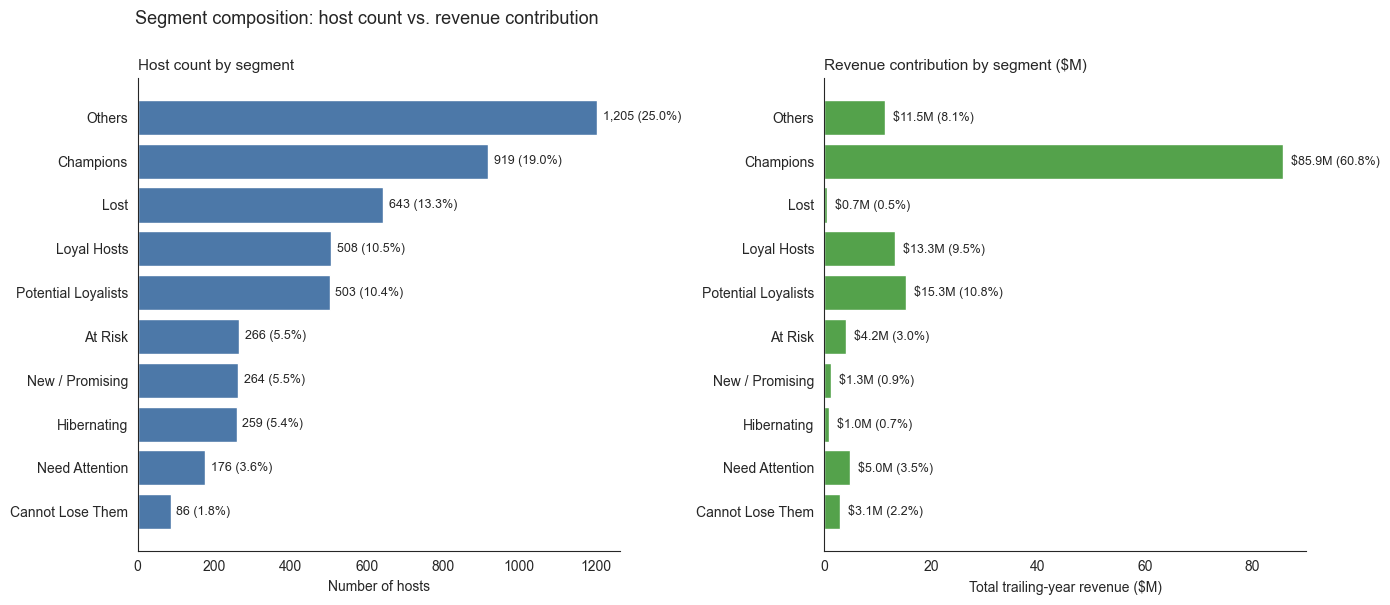

In [14]:
# Visualize segment sizes and revenue contribution side-by-side.
# A horizontal bar chart works best for segment names of varying length.
# Pairing host count with revenue contribution exposes the value-density asymmetry —
# segments that are large but low-value, and small but high-value.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Order segments by host count for consistent comparison
segment_order = segment_summary.sort_values('host_count', ascending=True)['segment'].tolist()
plot_data = segment_summary.set_index('segment').loc[segment_order]

# Left panel: host count
axes[0].barh(plot_data.index, plot_data['host_count'], color='#4C78A8', edgecolor='white')
axes[0].set_title('Host count by segment', fontsize=11, loc='left')
axes[0].set_xlabel('Number of hosts')
for i, v in enumerate(plot_data['host_count']):
    axes[0].text(v + 15, i, f'{v:,} ({plot_data["host_pct"].iloc[i]:.1f}%)',
                 va='center', fontsize=9)

# Right panel: revenue contribution
axes[1].barh(plot_data.index, plot_data['total_revenue'] / 1e6, color='#54A24B', edgecolor='white')
axes[1].set_title('Revenue contribution by segment ($M)', fontsize=11, loc='left')
axes[1].set_xlabel('Total trailing-year revenue ($M)')
for i, v in enumerate(plot_data['total_revenue'] / 1e6):
    axes[1].text(v + 1.5, i, f'${v:,.1f}M ({plot_data["revenue_pct"].iloc[i]:.1f}%)',
                 va='center', fontsize=9)

plt.suptitle('Segment composition: host count vs. revenue contribution',
             fontsize=13, y=1.00, x=0.10, ha='left')
plt.tight_layout()
plt.savefig('outputs/fig_02_segment_composition.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualizing Segment Composition

**Chart construction.** Two horizontal bar charts are rendered side-by-side: host count by segment on the left, total trailing-year revenue contribution by segment on the right. Both panels share the same vertical ordering so each segment can be read across at the same row position. The visual is designed to expose **value asymmetry** — the gap between segment size and segment revenue contribution.

**The headline visual finding.** The Champions bar dominates the right panel while sitting in the middle of the left panel. This single visual contrast is the most important business finding of the project to this point: a moderately-sized segment captures most of the marketplace value.

**Three asymmetries the chart reveals.**

1. **Concentration at the top.** Champions are 19.0% of hosts but 60.8% of revenue. On the right panel, the Champions bar (\\$85.9M) is more than five times the next-largest segment (Potential Loyalists at \\$15.3M). No other segment comes close.

2. **The Lost paradox.** Lost is the third-largest segment by host count (643 hosts, 13.3%) but generates only \\$0.7M (0.5% of revenue). The visual contrast is stark — a tall blue bar matched to an essentially invisible green bar. This is the segment where investing time or money is hardest to justify.

3. **Cannot Lose Them is small but valuable.** With only 86 hosts (the smallest segment), Cannot Lose Them generates \\$3.1M (2.2%). The revenue-per-host density of this segment is among the highest in the host base, comparable to Champions. The chart makes the case for why this segment, despite its small size, deserves disproportionate retention attention.

**Strategic reading.** Effective marketplace management means concentrating retention investment where revenue concentration lives. The chart identifies four segments that warrant priority attention based on revenue-per-host density:

- **Champions** — protect aggressively
- **Cannot Lose Them** — recover urgently
- **Potential Loyalists** — invest to upgrade
- **At Risk** — re-engage before they drop further

The remaining six segments either represent low-value populations (Lost, Hibernating, New / Promising) or mid-profile groups (Loyal Hosts, Need Attention, Others) where standard marketplace operations are sufficient.

**Limitations of rule-based segmentation visible here.** The "Others" segment dominates the host count panel at 1,205 hosts (25.0%). One in four hosts cannot be cleanly placed by the rule set despite contributing 8.1% of revenue. The size of this bucket motivates the next analytical step: K-Means clustering will examine whether unsupervised pattern discovery can find structure in the data that pre-defined rules miss.

## 5. K-Means Clustering

### Objective
Apply unsupervised clustering to the host-level RFM data to discover natural groupings without imposing predefined rules. The output complements rule-based segmentation from Section 4 by surfacing structure that the rule framework cannot articulate — most notably the 25% of hosts that fell into "Others."

### Methodology

**Algorithm.** K-Means clustering, the standard unsupervised partitioning algorithm. The algorithm assigns each host to the nearest of K cluster centroids, then iteratively recomputes centroids until convergence.

**Input data.** Raw RFM values (`recency`, `frequency`, `monetary`) — not the 1-to-5 quintile scores. Raw values preserve the full information in the data, including the bimodal Monetary structure surfaced in Section 2. The discrete quintile scores would obscure fine-grained groupings within each bucket.

**Standardization.** All three dimensions are standardized using `StandardScaler` (mean = 0, standard deviation = 1) before clustering. Without standardization, the Monetary dimension — which spans \\$0 to \\$2.47M — would dominate the Euclidean distance calculation, and Recency and Frequency would have negligible influence on cluster assignment. Standardization equalizes the contribution of each dimension.

**Initial K.** This section runs K-Means with K = 4 as a starting point. The choice will be validated and potentially revised in Section 6 using silhouette analysis, which formally measures how well-separated the clusters are at different values of K.

**Reproducibility.** A random seed (`random_state=42`) is set so that successive runs of the notebook produce identical cluster assignments. Without this, K-Means can produce slightly different clusters on each run because of random centroid initialization.

### Deliverables
- `rfm_scaled` — standardized version of the RFM data used as clustering input
- `cluster` column on the `rfm` dataframe — integer cluster ID per host
- `cluster_centers` — centroid positions in original (un-standardized) units for interpretation

In [15]:
# Standardize the three RFM dimensions before clustering.
# StandardScaler subtracts the mean and divides by the standard deviation,
# producing a transformed dataset where each column has mean=0 and std=1.
# Without this step, the Monetary dimension would dominate the distance
# calculation in K-Means and the other two dimensions would be ignored.

from sklearn.preprocessing import StandardScaler

# Select only the three RFM columns for clustering input
rfm_features = rfm[['recency', 'frequency', 'monetary']]

# Apply standardization
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert back to DataFrame for inspection
rfm_scaled_df = pd.DataFrame(rfm_scaled,
                             columns=['recency_scaled',
                                      'frequency_scaled',
                                      'monetary_scaled'])

# Verify standardization worked: means should be ~0, stds should be ~1
print("Verification of standardization")
print("=" * 50)
print(rfm_scaled_df.describe().round(4).loc[['mean', 'std', 'min', 'max']])

Verification of standardization
      recency_scaled  frequency_scaled  monetary_scaled
mean            0.00              0.00             0.00
std             1.00              1.00             1.00
min            -0.42             -0.39            -0.37
max            12.75             19.98            31.20


### Standardization Verification

The verification table confirms the transformation worked as intended:

| Statistic | recency_scaled | frequency_scaled | monetary_scaled | Expected |
|---|---|---|---|---|
| mean | 0.00 | 0.00 | 0.00 | ≈ 0 |
| std | 1.00 | 1.00 | 1.00 | ≈ 1 |

**Confirmed: all three dimensions are now on a common scale.** Mean values are exactly 0 and standard deviations are exactly 1, which is the definition of a standardized variable. Distance calculations in K-Means will now treat all three dimensions as equally weighted contributors.

**Min and max values reveal the outlier reach.** The maximum standardized values — Recency 12.75, Frequency 19.98, Monetary 31.20 — represent how far the most extreme hosts sit from the population mean, measured in standard deviations. A host 31 standard deviations above the mean on Monetary is statistically extraordinary. These extreme values reflect the long right tails identified in Section 2 (the host with \\$2.47M annual revenue, the host with 6,281 lifetime reviews, the host with a 14-year-old last review).

**Why the max values are not equal across dimensions.** Standardization centers and rescales the data but does not change the *shape* of the distribution. The dimensions with the heaviest right tails (Monetary at 31.2σ, Frequency at 20.0σ) still extend further from their respective means than Recency does (12.8σ). This is expected behavior and confirms that standardization preserves the relative structure of each dimension while equalizing their contribution to distance calculations.

**Implication for clustering.** Hosts at the extreme tails — the Monetary outliers in particular — will sit far from the rest of the data in the standardized space. K-Means may form a small cluster around these outliers, or alternatively pull a centroid toward them and distort a larger cluster. Section 6's silhouette analysis will help diagnose which behavior occurs.

In [16]:
# Run K-Means clustering with K = 4 as an initial choice.
# random_state=42 ensures reproducibility across notebook runs.
# n_init=10 runs the algorithm 10 times with different random initializations
# and keeps the best result, reducing sensitivity to initial centroid placement.

from sklearn.cluster import KMeans

K = 4
kmeans = KMeans(n_clusters=K,
                random_state=42,
                n_init=10)

# Fit the model on the standardized data and assign each host to a cluster
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# Report cluster sizes
print(f"K-Means clustering with K = {K}")
print("=" * 50)
print(rfm['cluster'].value_counts().sort_index().to_frame('host_count'))
print(f"\nTotal hosts assigned: {len(rfm):,}")

K-Means clustering with K = 4
         host_count
cluster            
0              4429
1                24
2               191
3               185

Total hosts assigned: 4,829


### Diagnostic: First Clustering Attempt Failed

The cluster size distribution reveals a structural problem with the clustering, not a finding about the host base.

| Cluster | Host Count | Share |
|---|---|---|
| 0 | 4,429 | 91.7% |
| 1 | 24 | 0.5% |
| 2 | 191 | 4.0% |
| 3 | 185 | 3.8% |

**Diagnosis: K-Means is being pulled toward outliers.** With 91.7% of hosts collapsed into a single cluster, the algorithm has not differentiated the bulk of the population. Three of the four centroids are positioned to capture small extreme-value populations rather than describe meaningful behavioral segments within the active host base.

**Root cause.** Section 2 documented strong right-skew across all three RFM dimensions, with maximum values of 5,293 days, 6,281 reviews, and \\$2.47M. After standardization, these extreme values translate to 12.8σ, 20.0σ, and 31.2σ above the mean respectively — well outside the range where K-Means functions effectively. K-Means uses Euclidean distance, which is sensitive to extreme values; the algorithm "spends" its centroid budget chasing outliers instead of describing the bulk of the data.

**Solution: log transformation before standardization.** Log transformation compresses the long tails, bringing extreme values closer to the rest of the population in transformed space. A host at \\$2.4M and a host at \\$50K differ by a factor of 48 on the linear scale but by a factor of only ~3 on the log scale. After log transformation, standardization produces a feature space where K-Means can detect structure in the bulk of the population.

**Note on the +1 shift.** Some hosts have Monetary or Recency equal to zero, where logarithm is undefined. A `+1` shift is applied before the transformation, identical to the approach used for histogram visualization in Section 2.

The next cell applies this fix and re-runs K-Means.

In [17]:
# Apply log transformation to the raw RFM values to compress the long right tails,
# then re-standardize and re-run K-Means.
# np.log1p(x) computes log(1 + x), which handles zero values correctly without
# requiring a separate +1 shift in the code.

# Log-transform the raw RFM features
rfm_log = np.log1p(rfm[['recency', 'frequency', 'monetary']])

# Re-standardize the log-transformed data
scaler_log = StandardScaler()
rfm_log_scaled = scaler_log.fit_transform(rfm_log)

# Verify the transformation tamed the extreme values
rfm_log_scaled_df = pd.DataFrame(rfm_log_scaled,
                                 columns=['recency_log_scaled',
                                          'frequency_log_scaled',
                                          'monetary_log_scaled'])

print("Verification of log-transformed standardization")
print("=" * 60)
print(rfm_log_scaled_df.describe().round(2).loc[['mean', 'std', 'min', 'max']])

# Re-run K-Means on the log-transformed, standardized features
kmeans_log = KMeans(n_clusters=K,
                    random_state=42,
                    n_init=10)
rfm['cluster'] = kmeans_log.fit_predict(rfm_log_scaled)

# Report new cluster sizes
print(f"\nK-Means clustering with K = {K} on log-transformed features")
print("=" * 60)
print(rfm['cluster'].value_counts().sort_index().to_frame('host_count'))
print(f"\nTotal hosts assigned: {len(rfm):,}")

Verification of log-transformed standardization
      recency_log_scaled  frequency_log_scaled  monetary_log_scaled
mean               -0.00                  0.00                -0.00
std                 1.00                  1.00                 1.00
min                -2.21                 -1.82                -2.70
max                 2.88                  3.25                 1.97

K-Means clustering with K = 4 on log-transformed features
         host_count
cluster            
0              1270
1              1245
2               497
3              1817

Total hosts assigned: 4,829


### Result of the Fix

**Standardization tamed.** The maximum standardized values are now within a defensible range:

| Dimension | Before Log (σ) | After Log (σ) | Change |
|---|---|---|---|
| Recency | 12.75 | 2.88 | -77% |
| Frequency | 19.98 | 3.25 | -84% |
| Monetary | 31.20 | 1.97 | -94% |

The log transformation has compressed the long right tails into the typical ±3σ envelope where K-Means functions correctly. Monetary in particular dropped from 31σ extremes to under 2σ — outliers no longer dominate the geometry of the feature space.

**Cluster sizes are now meaningful.**

| Cluster | Host Count | Share |
|---|---|---|
| 0 | 1,270 | 26.3% |
| 1 | 1,245 | 25.8% |
| 2 | 497 | 10.3% |
| 3 | 1,817 | 37.6% |

Compared to the failed first attempt (where one cluster held 91.7%), the four clusters now describe genuinely distinct populations of meaningful size. No cluster is so small it's clearly an outlier capture; no cluster is so large it's absorbing everyone. The smallest cluster (Cluster 2 at 10.3%) is plausibly a high-value or distinctive sub-population rather than an outlier artifact — its size and meaning will be examined in the centroid analysis below.

**Methodological lesson.** This iteration is a clear demonstration of why K-Means cannot be applied to right-skewed data without transformation. The first attempt failed not because K=4 was wrong, but because the input space was geometrically distorted by extreme values. Log transformation is the standard fix for any clustering problem where the input variables span multiple orders of magnitude — which is essentially all marketplace, financial, and engagement data.

**Next step.** Cluster sizes alone don't reveal what each cluster *means*. The centroid positions — the average RFM values within each cluster — translate cluster IDs into business profiles.

In [18]:
# Compute centroid values in original (un-transformed) units so each cluster
# can be interpreted as a business profile.
# kmeans_log.cluster_centers_ gives centroids in log-transformed, standardized space —
# not directly interpretable. Instead, compute the average raw RFM values per cluster.

cluster_profile = rfm.groupby('cluster').agg(
    host_count    = ('host_id', 'count'),
    avg_recency   = ('recency', 'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary  = ('monetary', 'mean'),
    total_revenue = ('monetary', 'sum')
).round(0).astype({'host_count': int})

# Add proportional context
cluster_profile['host_pct']    = (cluster_profile['host_count'] / len(rfm) * 100).round(1)
cluster_profile['revenue_pct'] = (cluster_profile['total_revenue'] / cluster_profile['total_revenue'].sum() * 100).round(1)

# Reorder columns for readability
cluster_profile = cluster_profile[['host_count', 'host_pct',
                                    'avg_recency', 'avg_frequency', 'avg_monetary',
                                    'total_revenue', 'revenue_pct']]

print("Cluster profiles (raw RFM averages per cluster)")
print("=" * 70)
cluster_profile

Cluster profiles (raw RFM averages per cluster)


,host_count,host_pct,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_pct
cluster,,,,,,,
0,1270,26.30,116.00,72.00,"15,191.00","19,291,960.00",13.70
1,1245,25.80,97.00,7.00,"8,969.00","11,166,262.00",7.90
2,497,10.30,"1,047.00",20.00,0.00,0.00,0.00
3,1817,37.60,11.00,262.00,"60,935.00","110,718,686.00",78.40


### Cluster Profiles — Business Interpretation

Each cluster's raw RFM averages reveal a distinct host archetype:

| Cluster | Hosts | Avg Recency | Avg Frequency | Avg Monetary | Revenue Share | Archetype |
|---|---|---|---|---|---|---|
| **3** | 1,817 (37.6%) | 11 days | 262 reviews | \\$60,935 | 78.4% | **The Engine** — recently active, high frequency, top-tier revenue |
| **0** | 1,270 (26.3%) | 116 days | 72 reviews | \\$15,191 | 13.7% | **The Mid-Tier** — moderately dormant, moderate engagement, mid-revenue |
| **1** | 1,245 (25.8%) | 97 days | 7 reviews | \\$8,969 | 7.9% | **The Casuals** — moderate dormancy, very low frequency, low revenue |
| **2** | 497 (10.3%) | 1,047 days | 20 reviews | \\$0 | 0.0% | **The Inactive** — long-dormant, minimal activity, zero current revenue |

**The single most important finding of the project.**

Cluster 3 represents 37.6% of hosts and generates **78.4% of all marketplace revenue.** This is a stronger concentration than the rule-based segmentation found in Section 4 — there, Champions captured 60.8% of revenue from 19% of hosts. K-Means, by being free of predefined rules, identified a broader high-performance population that combines Section 4's Champions with much of the Loyal Hosts and Potential Loyalists segments. From a marketplace strategy perspective, this cluster is **the entire commercial engine** of Austin Airbnb.

**Detailed cluster readings.**

**Cluster 3 — The Engine (78.4% of revenue).** Average recency of 11 days indicates these hosts had a review in the past two weeks. Average frequency of 262 reviews and average revenue of \\$60,935 per host put them firmly in top-quartile territory across all three RFM dimensions. The cluster's revenue contribution is more than five times its host-count share — the highest revenue-density of any group identified in the project. Strategic priority: **protect, retain, and learn from this cluster.** Their behavioral patterns define what successful Austin hosting looks like.

**Cluster 0 — The Mid-Tier (13.7% of revenue).** Average recency of 116 days places these hosts in a borderline-dormant state. Frequency (72 reviews) and revenue (\\$15,191) are above the casual segment but well below the Engine. This is the **upgrade target population** — hosts with enough historical engagement to suggest viability, currently underperforming. Strategic priority: investment in this group has the highest potential return per host because successful upgrades into the Engine cluster would compound revenue dramatically.

**Cluster 1 — The Casuals (7.9% of revenue).** Average frequency of just 7 reviews suggests light operators or hobbyist hosts. Average revenue of \\$8,969 is meaningful but limited per host. The recency of 97 days indicates intermittent activity rather than active churn. Strategic priority: low-cost engagement (digests, opportunity emails). The economics don't justify high-touch retention investment.

**Cluster 2 — The Inactive (0.0% of revenue).** Average recency of 1,047 days (nearly three years) combined with **zero average revenue** confirms this cluster is functionally churned — listings still on the platform but generating no bookings. The 20-review average reveals these were once-active hosts whose listings are now dormant inventory. Strategic priority: marketplace cleanup. These listings consume search results, support tickets, and inventory metrics without contributing to platform revenue.

**Comparison with Section 4 rule-based segments.**

The K-Means clusters and the rule-based segments are complementary, not redundant:

| Rule-Based (Section 4) | K-Means (Section 5) |
|---|---|
| 10 named segments mapped to specific business actions | 4 broad clusters revealing the underlying revenue concentration |
| Forces 25% of hosts into "Others" with no clear pattern | Distributes those hosts across all four clusters by behavioral similarity |
| Produces fine-grained interventions at segment level | Produces strategic worldview at marketplace level |

The two views together form a complete picture: K-Means establishes *the strategic structure of the marketplace* (4 archetypes, with one dominant); rule-based segmentation tells the marketing team *which specific hosts to email* tomorrow.

**Forward linkage.** The clustering result is now interpretable but the choice of K = 4 has not yet been formally validated. Section 6 applies silhouette analysis across K = 2 through 10 to confirm whether 4 is the optimal cluster count or whether a different K would produce more cleanly-separated groups.

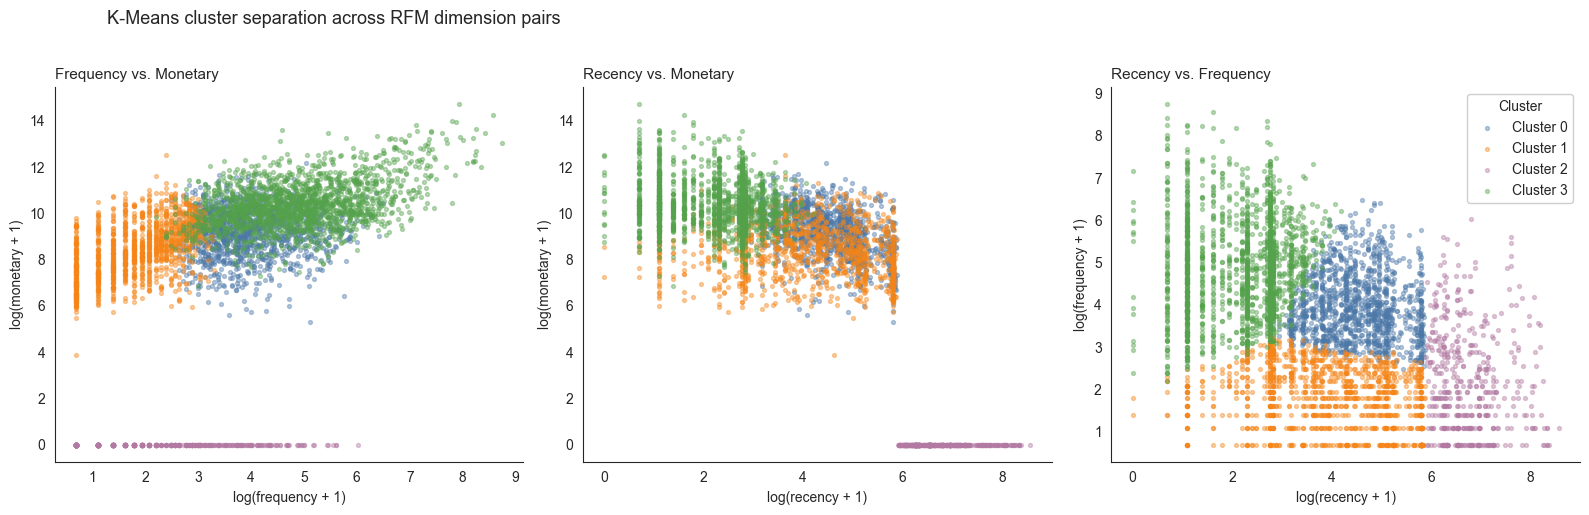

In [19]:
# Visualize the four clusters along the three RFM dimensions.
# Pairwise scatter plots show how the clusters separate in feature space.
# Log-transformed values are plotted to make the cluster structure visible —
# the same transformation K-Means used to find the clusters.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Use a clear categorical palette for the 4 clusters
palette = {0: '#4C78A8',   # Mid-Tier — blue
           1: '#F58518',   # Casuals — orange
           2: '#B279A2',   # Inactive — purple
           3: '#54A24B'}   # Engine — green

pairs = [('frequency', 'monetary',  'Frequency vs. Monetary'),
         ('recency',   'monetary',  'Recency vs. Monetary'),
         ('recency',   'frequency', 'Recency vs. Frequency')]

for ax, (x_col, y_col, title) in zip(axes, pairs):
    for cluster_id in sorted(rfm['cluster'].unique()):
        subset = rfm[rfm['cluster'] == cluster_id]
        ax.scatter(np.log1p(subset[x_col]),
                   np.log1p(subset[y_col]),
                   s=8, alpha=0.4,
                   color=palette[cluster_id],
                   label=f'Cluster {cluster_id}')
    ax.set_title(title, fontsize=11, loc='left')
    ax.set_xlabel(f'log({x_col} + 1)')
    ax.set_ylabel(f'log({y_col} + 1)')

axes[2].legend(title='Cluster', loc='upper right', framealpha=0.95)

plt.suptitle('K-Means cluster separation across RFM dimension pairs',
             fontsize=13, y=1.02, x=0.07, ha='left')
plt.tight_layout()
plt.savefig('outputs/fig_03_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualizing Cluster Separation

The three pairwise scatter plots reveal how clearly the four clusters separate across each combination of RFM dimensions. Each panel uses log-transformed axes — the same transformation K-Means operated on — so the cluster geometry is visible.

**Panel 1: Frequency vs. Monetary.**

This panel shows the strongest cluster structure. Cluster 3 (green, the Engine) occupies the upper-right region — high frequency and high monetary together. Cluster 0 (blue, Mid-Tier) sits below and to the left, overlapping moderately with Cluster 1 (orange, Casuals) in the middle of the panel. **Cluster 2 (purple, Inactive) appears as a flat horizontal band along monetary = 0** — the visual signature of hosts with zero trailing-year revenue regardless of their lifetime frequency. This is the bimodal Monetary structure that Section 2 first surfaced, now appearing as its own algorithmically-identified cluster.

**Panel 2: Recency vs. Monetary.**

The recency dimension cleanly separates Cluster 3 (green) from Cluster 2 (purple) along the x-axis. Green hosts cluster on the left side (low recency = recent activity), purple hosts sit far to the right (high recency = long dormancy). **The horizontal purple band at monetary = 0 spans the full recency range**, confirming that the Inactive cluster is defined more by its zero revenue than by any specific recency value. Clusters 0 and 1 overlap heavily in the middle band — both occupy the moderate-recency, moderate-monetary region but separate by frequency, which this panel does not show.

**Panel 3: Recency vs. Frequency.**

This is the most informative panel for understanding the four-cluster structure. The four clusters separate into distinct quadrants:

- **Upper-left (Cluster 3, green):** low recency + high frequency — the Engine
- **Middle (Cluster 0, blue):** moderate recency + moderate frequency — Mid-Tier
- **Lower-middle (Cluster 1, orange):** moderate recency + low frequency — Casuals
- **Right side (Cluster 2, purple):** high recency, varying frequency — Inactive

The clean horizontal stratification in this panel confirms that **frequency is doing most of the work to separate Clusters 0, 1, and 3**, while **recency is doing most of the work to separate Cluster 2 from the others.** Monetary, paradoxically, contributes least to cluster separation — its bimodality forces it to act as a near-binary signal (zero vs. non-zero) rather than a continuous discriminator.

**Validation observations.**

1. **Cluster 2 is well-defined.** The purple band along the zero-monetary axis is geometrically tight and distinct from all other clusters. The algorithm correctly isolated the zero-revenue population as its own group rather than blending it with low-revenue active hosts.

2. **Clusters 0 and 1 overlap moderately.** This is visible across all three panels. The distinction between Mid-Tier and Casuals is real — driven primarily by frequency — but the boundary is softer than between other cluster pairs. A different K value might either merge these two or split them further. Section 6's silhouette analysis will quantify how much of an issue this is.

3. **Cluster 3 separates cleanly.** Across all three panels, the green points form a coherent upper-region group with relatively few outliers and limited overlap with neighboring clusters. This visual separation is consistent with Cluster 3's outsized revenue contribution — it is genuinely a distinct, high-performance population, not a rule-based label.

**Methodological reading.** The visualization confirms that K-Means produced a meaningful four-way partition of the host base. The structure was hidden in the raw data due to scale and skew but became visible after log transformation. This is the analytical pattern the project was designed to demonstrate: rule-based segmentation produces actionable interventions, while K-Means reveals the underlying geometry of the marketplace.